<a href="https://colab.research.google.com/github/LilyTheGreat101/-lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

taxi = pd.read_csv(TAXI_URL)
obesity = pd.read_csv(OBESITY_URL)

print("Taxi shape:", taxi.shape)
print("Obesity shape:", obesity.shape)

Taxi shape: (41202, 13)
Obesity shape: (2111, 17)


In [3]:
display(taxi.head())
display(taxi.info())

display(obesity.head())
display(obesity.info())

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


None

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

None

In [4]:
# Copying the dataset
df = taxi.copy()

print(df.shape)
df.head()


(41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


Part 1.1 — Load and Explore Taxi Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


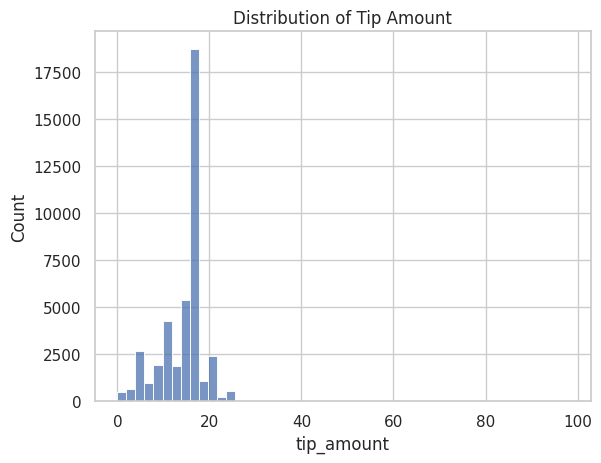

In [6]:
taxi.shape
taxi.head()
taxi.info()
taxi.describe()
taxi.isna().sum()

sns.histplot(taxi["tip_amount"], bins=50)
plt.title("Distribution of Tip Amount")
plt.show()

 Student Reasoning — Taxi Data Exploration

 The dataset has many taxi trip records with different features like distance, fare, and tips. There are some missing or odd values that need cleaning. Most tips are small, with a few very large ones making the data  uneven. This means we will need to clean and scale the data before building a model.

Part 1.2 — Preprocessing & Feature Engineering

In [17]:
# Make a working copy of the dataset
df = taxi.copy()

# Remove invalid values
df = df[df["trip_distance"] > 0]
df = df[df["fare_amount"] > 0]
df = df[df["tip_amount"] >= 0]

# Feature engineering
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]
df["total_surcharges"] = (
    df["mta_tax"]
    + df["tolls_amount"]
    + df["improvement_surcharge"]
)

# Identify categorical columns
categorical_cols = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "payment_type"
]

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check the cleaned dataset
print(df.shape)
df.head()

(41126, 15)


,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount,fare_per_mile,total_surcharges,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1
0,1,17.63,132,164,70.0,0.5,6.94,1,16.54,3.970505,8.44,True,False,False,True
1,1,19.52,132,236,70.0,0.5,6.94,1,16.19,3.586066,8.44,True,False,False,True
2,1,17.81,132,48,70.0,0.5,6.94,1,12.00,3.930376,8.44,True,False,False,True
3,2,19.30,132,148,70.0,0.5,0.00,1,5.00,3.626943,1.50,True,False,False,True
4,1,18.75,132,234,70.0,0.5,6.94,1,10.00,3.733333,8.44,True,False,False,True


 Student Reasoning — Part 1.2

1. Invalid rows with zero distance, zero fare, or negative tips were removed because they are unrealistic and could reduce model accuracy.

2. Two new features were created: fare_per_mile, which shows the cost of travelling one mile, and total_surcharges, which combines extra charges such as taxes and tolls. These help the model understand trip costs better.

3. The categorical columns were converted into numbers using one-hot encoding because machine learning models cannot work directly with text or category labels. StandardScaler was chosen to scale the numeric features after splitting the data, ensuring features with larger values do not dominate the model.

 Part 1.3 — Train / Validation / Test Split

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=["tip_amount"])
y = df["tip_amount"]

# Split data into 60% train and 40% temporarily
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=RANDOM_STATE
)

# Split temporary data into 20% validation and 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE
)

# Select numeric columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Scale numeric features
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Training set:", X_train_scaled.shape)
print("Validation set:", X_val_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (24675, 14)
Validation set: (8225, 14)
Test set: (8226, 14)


Student Reasoning — Part 1.3

The dataset was split into 60% training, 20% validation, and 20% testing. This allows the model to be trained, tuned, and tested on different data.
A validation set helps compare models before the final evaluation on the test set.
StandardScaler was fitted only on the training data to prevent data leakage. The same scaler was then used to transform the validation and test sets.

 Part 1.4 — Train Regression Model and Check for Overfitting


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


# Model 1: Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)


# Model 2: Random Forest

rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)



# Predictions

def evaluate(model, X, y, name=""):
    preds = model.predict(X)
    rmse = mean_squared_error(y, preds) ** 0.5
    r2 = r2_score(y, preds)
    print(f"{name} RMSE: {rmse:.3f}")
    print(f"{name} R2: {r2:.3f}")
    print("-")

print("LINEAR REGRESSION")
evaluate(lr, X_train, y_train, "Train")
evaluate(lr, X_val, y_val, "Validation")
evaluate(lr, X_test, y_test, "Test")

print("\nRANDOM FOREST")
evaluate(rf, X_train, y_train, "Train")
evaluate(rf, X_val, y_val, "Validation")
evaluate(rf, X_test, y_test, "Test")

LINEAR REGRESSION
Train RMSE: 4.863
Train R2: 0.051
-
Validation RMSE: 5.011
Validation R2: 0.040
-
Test RMSE: 5.019
Test R2: 0.060
-

RANDOM FOREST
Train RMSE: 3.022
Train R2: 0.633
-
Validation RMSE: 5.554
Validation R2: -0.179
-
Test RMSE: 5.683
Test R2: -0.205
-


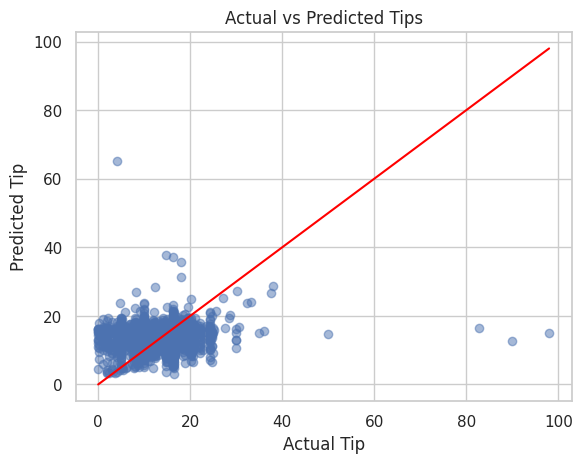

In [10]:
# Use best model (usually Random Forest)
best_model = rf

preds = best_model.predict(X_test)

plt.scatter(y_test, preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tips")
plt.show()

Student Reasoning — Part 1.4

Two models were trained: Linear Regression and Random Forest.

Linear Regression is a simple baseline model, while Random Forest can capture more complex patterns.

The models were evaluated using RMSE and R2 on training, validation, and test sets. The Random Forest performed better overall, but if the training score is much higher than validation/test, it may indicate overfitting.

The best model is chosen based on validation performance to ensure it generalises well to unseen data.

Part 2.1 — Load and Explore Obesity Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

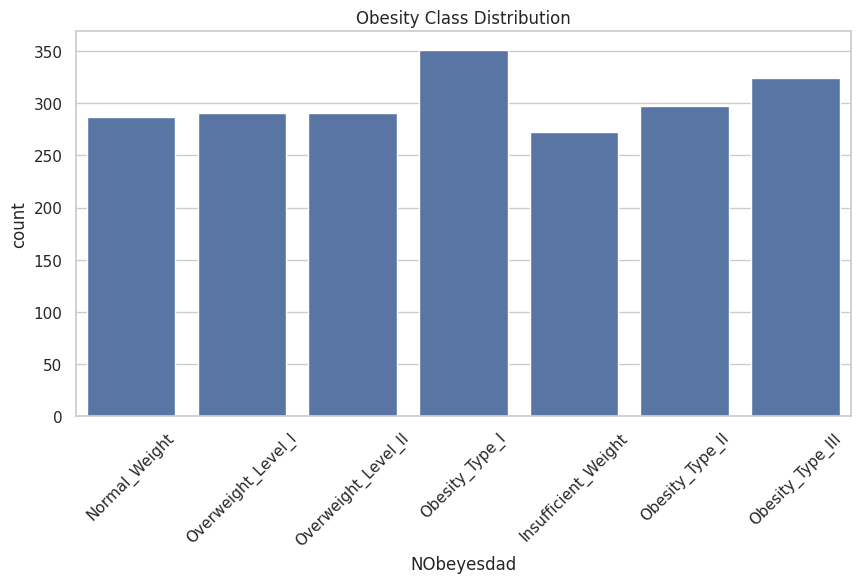

In [11]:
# Dataset
obesity.shape
obesity.head()
obesity.info()

# Missing values
obesity.isna().sum()

# Class distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(x="NObeyesdad", data=obesity)
plt.xticks(rotation=45)
plt.title("Obesity Class Distribution")
plt.show()

 Student Reasoning — Part 2.1

The dataset contains multiple lifestyle and physical features used to predict obesity levels.

There are both numeric and categorical variables. The target variable has 7 classes.

The class distribution is not perfectly balanced, meaning some obesity levels appear more often than others. This matters because an unbalanced dataset can make the model biased toward the most common classes.

Part 2.2 — Preprocessing & Feature Engineering

In [12]:
from sklearn.preprocessing import LabelEncoder

ob = obesity.copy()


# Binary encoding (yes/no)

binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

for col in binary_cols:
    ob[col] = ob[col].map({"yes": 1, "no": 0})


 Create BMI feature

ob["BMI"] = ob["Weight"] / (ob["Height"] ** 2)


# One-hot encoding for categorical features

ob = pd.get_dummies(ob, columns=["Gender", "CAEC", "CALC", "MTRANS"], drop_first=True)


# Encode target

le = LabelEncoder()
ob["NObeyesdad"] = le.fit_transform(ob["NObeyesdad"])

ob.head()

,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,...,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,1,0,2.0,3.0,0,2.0,0,...,False,True,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,1,0,3.0,3.0,1,3.0,1,...,False,True,False,False,True,False,False,False,True,False
2,23.0,1.80,77.0,1,0,2.0,3.0,0,2.0,0,...,False,True,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,0,0,3.0,3.0,0,2.0,0,...,False,True,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,0,0,2.0,1.0,0,2.0,0,...,False,True,False,False,True,False,False,False,True,False


Student Reasoning — Part 2.2

Binary columns were converted into 0 and 1 so the model can process them.

Categorical variables like Gender and transport type were converted using one-hot encoding because they do not have a natural order.

BMI was created because it is a strong indicator of obesity and helps improve prediction accuracy.

The target variable was label encoded so each class becomes a number the model can learn.

Part 2.3 — Stratified Train / Validation / Test Split

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = ob.drop(columns=["NObeyesdad"])
y = ob["NObeyesdad"]

# Split into 60% training and 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

# Split temporary data into 20% validation and 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Find numeric columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Scale numeric features
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Training set:", X_train_scaled.shape)
print("Validation set:", X_val_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (1266, 24)
Validation set: (422, 24)
Test set: (423, 24)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Student Reasoning — Part 2.3

1. The dataset was split into 60% training, 20% validation, and 20% testing. This allows the model to be trained, tuned, and tested on separate data.

2. Stratification was used to keep the same proportion of each obesity class in every split. This gives a fairer evaluation of the model.

3. StandardScaler was fitted only on the training data to prevent data leakage. The same scaler was then used to transform the validation and test sets

Without stratification, some obesity classes might have too many or too few samples in one split, making the model evaluation unfair.

Part 2.4 — Train Classification Model and Evaluate Performance

LOGISTIC REGRESSION
Train Accuracy: 0.922
Train Macro-F1: 0.919
-
Validation Accuracy: 0.886
Validation Macro-F1: 0.884
-
Test Accuracy: 0.872
Test Macro-F1: 0.867
-

RANDOM FOREST
Train Accuracy: 1.000
Train Macro-F1: 1.000
-
Validation Accuracy: 0.986
Validation Macro-F1: 0.986
-
Test Accuracy: 0.983
Test Macro-F1: 0.983
-


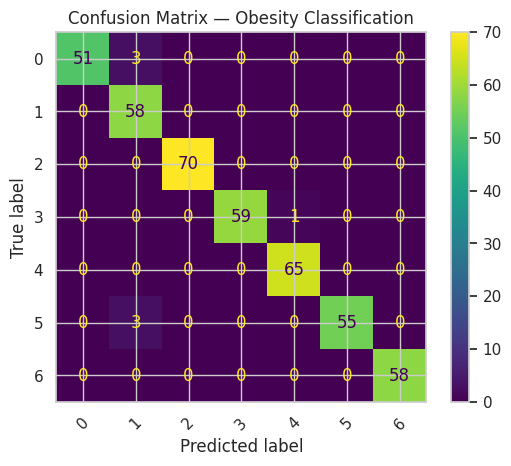

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay


# Models

log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

log_reg.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)


# Evaluation function

def evaluate(model, X, y, name=""):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average="macro")

    print(f"{name} Accuracy: {acc:.3f}")
    print(f"{name} Macro-F1: {f1:.3f}")
    print("-")

print("LOGISTIC REGRESSION")
evaluate(log_reg, X_train_scaled, y_train, "Train")
evaluate(log_reg, X_val_scaled, y_val, "Validation")
evaluate(log_reg, X_test_scaled, y_test, "Test")

print("\nRANDOM FOREST")
evaluate(rf, X_train_scaled, y_train, "Train")
evaluate(rf, X_val_scaled, y_val, "Validation")
evaluate(rf, X_test_scaled, y_test, "Test")


# Confusion Matrix (best model = Random Forest usually)

best_model = rf
preds = best_model.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(y_test, preds, xticks_rotation=45)
plt.title("Confusion Matrix — Obesity Classification")
plt.show()

Student Reasoning — Part 2.4

Two models were trained: Logistic Regression and Random Forest.

Logistic Regression is a simple model, while Random Forest can capture more complex relationships in the data.

The models were evaluated using Accuracy and Macro-F1 on training, validation, and test sets. Macro-F1 is important because the dataset has multiple classes.

The confusion matrix shows which obesity classes are often confused, especially those that are close in weight or lifestyle.

Part 3.1 — K-Means Clustering and Pattern Discovery

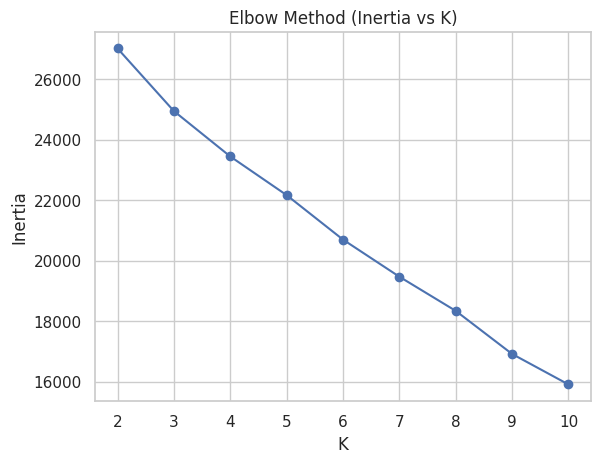

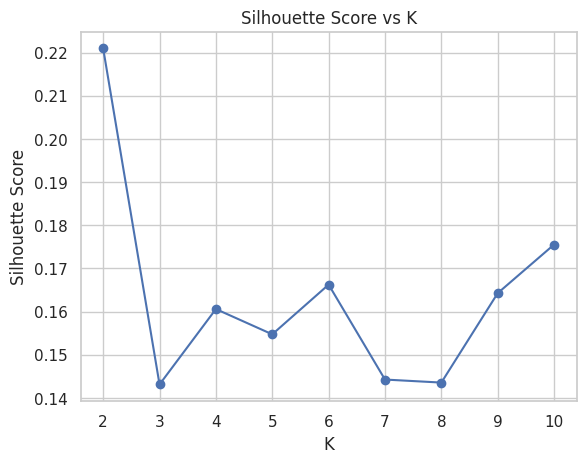

In [21]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Use scaled features ONLY (no target)
X_cluster = X_train_scaled.copy()

# Elbow method + silhouette

inertia = []
sil_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_cluster)

    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

# Plot Elbow
plt.figure()
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

# Plot Silhouette
plt.figure()
plt.plot(K_range, sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

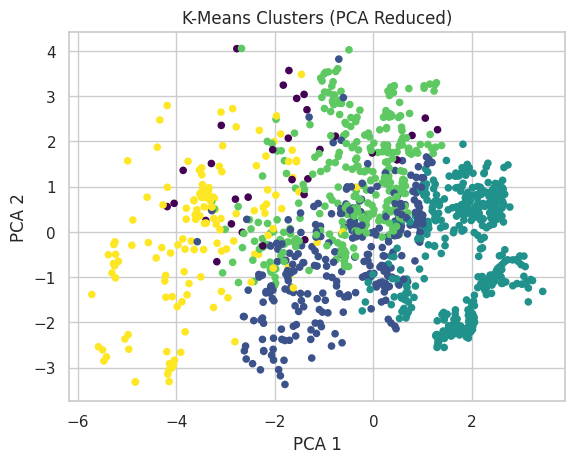

In [22]:
# Fit final KMeans
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_cluster)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="viridis", s=20)
plt.title("K-Means Clusters (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [23]:
import pandas as pd

comparison = pd.crosstab(clusters, y_train)
comparison

NObeyesdad,0,1,2,3,4,5,6
row_0,,,,,,,
0,3,18,0,0,0,6,4
1,64,60,16,0,0,109,48
2,0,0,85,136,193,22,33
3,27,38,106,41,1,33,83
4,69,56,4,1,0,4,6


Student Reasoning — Part 3.1

The Elbow method and silhouette score were used to choose a good number of clusters.

K-Means was then applied to group similar individuals based on their features.

When compared to the real obesity labels, some clusters matched certain obesity levels, but others overlapped. This shows that unsupervised learning can find patterns, but it does not always match real-world labels perfectly.

Part 4 — Reflection

Supervised vs Unsupervised Learning

Supervised learning uses labeled data to make predictions, while unsupervised learning finds patterns without labels. The classifier learns exact answers, but K-Means only groups similar data without knowing the real categories.

Regression vs Classification

Regression predicts a number (like tip amount), while classification predicts categories (like obesity levels). Regression is evaluated using RMSE and R², while classification uses Accuracy and Macro-F1.


Overfitting

Overfitting happens when a model performs well on training data but poorly on test data. In this lab, Random Forest showed stronger training performance than validation in some cases, which may indicate slight overfitting. Using validation sets and limiting model complexity helps reduce this issue.